# Imports and Loads

In [1]:
TRAIN_PATH = r'C:\Users\harwi\Downloads\student_health_risk_prediction_system\train.csv'
TEST_PATH = r'C:\Users\harwi\Downloads\student_health_risk_prediction_system\test.csv'

OOF_CAT = r'C:\Users\harwi\Downloads\student_health_risk_prediction_system\models\oof_cat_new.npy'
OOF_LGB = r'C:\Users\harwi\Downloads\student_health_risk_prediction_system\models\oof_lightgbm.npy'
OOF_XGB = r'C:\Users\harwi\Downloads\student_health_risk_prediction_system\models\oof_xgboost.npy'

TEST_CAT = r'C:\Users\harwi\Downloads\student_health_risk_prediction_system\models\test_cat_new.npy'
TEST_LGB = r'C:\Users\harwi\Downloads\student_health_risk_prediction_system\models\test_lightgbm.npy'
TEST_XGB = r'C:\Users\harwi\Downloads\student_health_risk_prediction_system\models\test_xgboost.npy'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score
import optuna

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

oof_cat= np.load(OOF_CAT)
oof_lgb= np.load(OOF_LGB)
oof_xgb = np.load(OOF_XGB)

test_cat= np.load(TEST_CAT)
test_lgb= np.load(TEST_LGB)
test_xgb = np.load(TEST_XGB)


c:\Users\harwi\anaconda3\envs\gpu_torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
OOF = {
    "cat": oof_cat,
    "lgb": oof_lgb,
    "xgb": oof_xgb,
}

TEST = {
    "cat": test_cat,
    "lgb": test_lgb,
    "xgb": test_xgb,
}

MODELS = {
    "CatBoost": oof_cat,
    "LightGBM": oof_lgb,
    "XGBoost": oof_xgb,
}

In [4]:
lb = LabelEncoder()
y_kag = lb.fit_transform(train['health_condition'])

# Analysising the models

In [5]:
predictions = {}

for name, probs in MODELS.items():
    predictions[name] = probs.argmax(axis=1)

model_names = list(predictions.keys())

agreement = pd.DataFrame(
    index=model_names,
    columns=model_names,
    dtype=float
)

In [6]:
for model1 in model_names:

    for model2 in model_names:

        same_prediction = (
            predictions[model1]
            ==
            predictions[model2]
        )

        agreement.loc[model1, model2] = same_prediction.mean()

In [7]:
agreement.head()

,CatBoost,LightGBM,XGBoost
CatBoost,1.000000,0.97497,0.936159
LightGBM,0.974970,1.00000,0.960720
XGBoost,0.936159,0.96072,1.000000


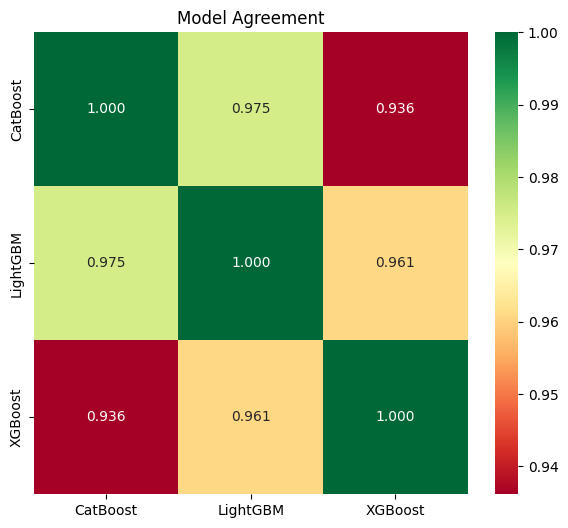

In [8]:
plt.figure(figsize=(7,6))

sns.heatmap(
    agreement,
    annot=True,
    cmap="RdYlGn",
    fmt=".3f"
)

plt.title("Model Agreement")
plt.show()

In [9]:
distribution = pd.DataFrame()

for name in model_names:

    pred = predictions[name]

    percent = (
        pd.Series(pred)
        .value_counts(normalize=True)
        .sort_index()
    )

    distribution[name] = percent

In [10]:
distribution = distribution.T
print(distribution)

                 0         1         2
CatBoost  0.809423  0.074795  0.115782
LightGBM  0.834110  0.066545  0.099345
XGBoost   0.873257  0.052430  0.074314


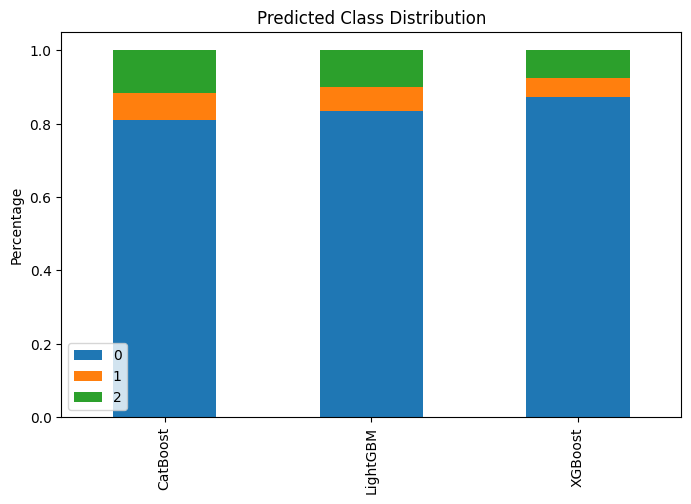

In [11]:
distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.ylabel("Percentage")
plt.title("Predicted Class Distribution")
plt.show()

**Observation**- According to the above analysis we can conclude there  is diversity in the models. Therefore there are changes that we get some benefit from blending.

### Using Arithmetic Mean for Blending

In [14]:
weights = {
    "cat": 0.60,
    "lgb": 0.30,
    "xgb": 0.10,
}

In [15]:
blend_oof = np.zeros_like(oof_cat)

for name in weights:
    blend_oof += weights[name] * OOF[name]

pred = blend_oof.argmax(axis=1)

score = balanced_accuracy_score(
    y_kag,
    pred
)

print(score)

0.947676456726847


In [ ]:
# blend_test = np.zeros_like(test_cat)

# for name in weights:
#     blend_test += weights[name] * TEST[name]

# submission = train['id'].copy()

# pred = blend_test.argmax(axis=1)

# submission["health_condition"] = lb.inverse_transform(pred)

# submission.to_csv(
#     "submission_blend_gm.csv",
#     index=False
# )

## Geometric mean


In [18]:
eps = 1e-15

blend_oof = np.zeros_like(oof_cat)

for name in weights:
    blend_oof += weights[name] * np.log(np.clip(OOF[name], eps, 1.0))

blend_oof = np.exp(blend_oof)

# Normalize so each row sums to 1
blend_oof = blend_oof / blend_oof.sum(axis=1, keepdims=True)

pred = blend_oof.argmax(axis=1)

score = balanced_accuracy_score(
    y_kag,
    pred
)

print(score)

eps = 1e-15

blend_test = np.zeros_like(test_cat)

for name in weights:
    blend_test += weights[name] * np.log(np.clip(TEST[name], eps, 1.0))

blend_test = np.exp(blend_test)

blend_test = blend_test / blend_test.sum(axis=1, keepdims=True)

pred = blend_test.argmax(axis=1)

# submission.drop(columns = ['health_condition'],inplace = True)
# submission["health_condition"] = lb.inverse_transform(pred)

# submission.to_csv(
#     "submission_blend_gm.csv",
#     index=False
# )

0.9474316090883406


# Automatic Weight Imputation using optuna for arithmetic mean

In [19]:
def objective(trial):

    weights = {}

    for model in OOF.keys():
        weights[model] = trial.suggest_float(
            model,
            0.0,
            1.0
        )

    # Normalize weights
    total = sum(weights.values())

    weights = {
        k: v / total
        for k, v in weights.items()
    }

    blend = np.zeros_like(next(iter(OOF.values())))

    for model in OOF.keys():
        blend += weights[model] * OOF[model]

    pred = blend.argmax(axis=1)

    score = balanced_accuracy_score(
        y_kag,
        pred
    )

    return score

In [20]:
study = optuna.create_study(
    direction="maximize",
    study_name="blend_weights",
    storage="sqlite:///blend.db",
    load_if_exists=True
)

study.optimize(
    objective,
    n_trials=300,
    show_progress_bar=True
)

[I 2026-07-25 15:13:17,743] A new study created in RDB with name: blend_weights
Best trial: 1. Best value: 0.943805:   1%|          | 2/300 [00:00<00:55,  5.38it/s]

[I 2026-07-25 15:13:17,960] Trial 0 finished with value: 0.9349355562228819 and parameters: {'cat': 0.5685801711111624, 'lgb': 0.9554761211739583, 'xgb': 0.7771149660976926}. Best is trial 0 with value: 0.9349355562228819.
[I 2026-07-25 15:13:18,130] Trial 1 finished with value: 0.9438048699915074 and parameters: {'cat': 0.9730837467656986, 'lgb': 0.5124765433828825, 'xgb': 0.5270609254629837}. Best is trial 1 with value: 0.9438048699915074.


Best trial: 1. Best value: 0.943805:   1%|          | 3/300 [00:00<00:55,  5.36it/s]

[I 2026-07-25 15:13:18,304] Trial 2 finished with value: 0.9162179916407988 and parameters: {'cat': 0.38966441428476406, 'lgb': 0.07502173518563715, 'xgb': 0.9628120781184681}. Best is trial 1 with value: 0.9438048699915074.


Best trial: 4. Best value: 0.94681:   1%|▏         | 4/300 [00:00<00:56,  5.26it/s] 

...

[I 2026-07-25 15:14:14,628] Trial 295 finished with value: 0.9495657209108077 and parameters: {'cat': 0.9997550476288872, 'lgb': 0.00010721608450943096, 'xgb': 0.018785822191717597}. Best is trial 129 with value: 0.949628449713754.
[I 2026-07-25 15:14:14,798] Trial 296 finished with value: 0.9495589541053331 and parameters: {'cat': 0.9665095316559177, 'lgb': 0.03683212654186796, 'xgb': 0.0001662477282711938}. Best is trial 129 with value: 0.949628449713754.


Best trial: 129. Best value: 0.949628: 100%|█████████▉| 299/300 [00:57<00:00,  5.57it/s]

[I 2026-07-25 15:14:14,970] Trial 297 finished with value: 0.9495038126453789 and parameters: {'cat': 0.9415164583728551, 'lgb': 0.023658414981445143, 'xgb': 0.033755147958632645}. Best is trial 129 with value: 0.949628449713754.
[I 2026-07-25 15:14:15,129] Trial 298 finished with value: 0.9492109036154934 and parameters: {'cat': 0.9794090103210243, 'lgb': 0.34341253262769506, 'xgb': 0.0004628697881592253}. Best is trial 129 with value: 0.949628449713754.


Best trial: 129. Best value: 0.949628: 100%|██████████| 300/300 [00:57<00:00,  5.21it/s]

[I 2026-07-25 15:14:15,296] Trial 299 finished with value: 0.9494189370160712 and parameters: {'cat': 0.9297612713325525, 'lgb': 0.0173187278693495, 'xgb': 0.06455408320407256}. Best is trial 129 with value: 0.949628449713754.


In [21]:
print("Best Score")
print(study.best_value)

print()

print("Weights")

print(study.best_params)

Best Score
0.949628449713754

Weights
{'cat': 0.824628073704747, 'lgb': 0.0034811160968560573, 'xgb': 0.00032888194728397744}


# Conclusion

We do not get any improvement in the balanced accuray with blending. In fact the balanced accuracy is decreased form individual catboost balanced acuracy. Therefore we will be not be using blending in our application.
 